## questions for rong & siyu:

- mixed layer depth -> 100 hpa? 50 hpa?


#### notes:

- download surface humidity & surface temperature 
- update pressure humidity and temperature profiles with correct surface values 
- update geopotential height for surface using thickness_hydrostatic
- now all profiles will be shape: [surface, model level 1, model level 2, ...]
- create a mixed layer parcel and update pressure, humidity and temperature with mixed layer values
- run through buoyancy 


#### notes: 
- 92W-110W, 25-38N -> SGP 
- 92W-110W, 38N-50N -> NGP

In [1]:
import pandas as pd
import importlib
import os
import sys
sys.path.append(os.path.abspath('..'))
import func
importlib.reload(func)
from func import cal_buoyancy
import glob
import os
import re
import datetime
import metpy.calc as mpcalc
from metpy.calc import dewpoint_from_specific_humidity, mixed_parcel, specific_humidity_from_dewpoint, thickness_hydrostatic, geopotential_to_height
from metpy.units import units
import metpy.constants as mpconsts
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from scipy.interpolate import interp1d
from scipy.optimize import bisect
import numpy as np
import pickle
import numpy as np
import math
import pint
import xarray as xr
import netCDF4 as nc
import re
import matplotlib.pyplot as plt
from numpy import load
from numpy import asarray
from numpy import save
import pytz
import dask.array as da
from scipy import stats
from sklearn.linear_model import LinearRegression
from collections import Counter
import pymannkendall as mk
%matplotlib inline

### Loading all necessary data

In [2]:
path = "/data/rong4/Siyu/data_ERA5/NEW_to_2024/"

g = 9.81 # m*s^2

q = xr.open_dataset(path + "ERA5_daily_from_6h_USA_q_1979_2024.nc")["q"] * 1000 #g/kg 

t = xr.open_dataset(path + "ERA5_daily_from_6h_USA_t_1979_2024.nc")["t"] #Kelvin

geopotential = xr.open_dataset(path + "ERA5_daily_from_6h_USA_z_1979_2024.nc")["z"] #m^2/s^2 

z = geopotential_to_height(geopotential * units.m**2 / units.s**2) #meters

# --- Create Gregorian date range for the time dimension ---

n_time = q.sizes["time"]      # number of days in dataset

dates = pd.date_range("1979-01-01", periods=n_time, freq="D")

# --- Assign new time coordinates ---

q = q.assign_coords(time=dates)

t = t.assign_coords(time=dates)

z = z.assign_coords(time=dates)

# Trim to SGP and NGP domains only

lat_slice = slice(25, 50)

lon_slice = slice(-110, -92)

q = q.sel(lat=lat_slice, lon=lon_slice)

t = t.sel(lat=lat_slice, lon=lon_slice)

geopotential = geopotential.sel(lat=lat_slice, lon=lon_slice)

lats = q['lat'].data

lons = q['lon'].data

p = q['level'].data #hpa

In [3]:
## files for surface pressure 

sp = xr.open_dataset(path + "ERA5_daily_from_6h_USA_surface_pressure_1979_2024.nc")["sp"] / 100 #hPa

sp = sp.assign_coords(time=dates)

sp = sp.sel(lat=lat_slice, lon=lon_slice)

sp = sp.sortby("lat")

In [4]:
# # files for surface dewpoint

# base_dir = "/home/annierosen16/data/siyu_gp_drought"

# _2m_dewpoint_folder = os.path.join(base_dir, "2m_dewpoint_temperature")

# _2m_dewpoint_files = sorted(glob.glob(os.path.join(_2m_dewpoint_folder, "*.nc")))

# _2m_dp = xr.open_mfdataset(
    
#     _2m_dewpoint_files,
    
#     combine="nested",
    
#     concat_dim="time",
    
#     parallel=False,
    
#     chunks={"time": 30}
# )

# _2m_dp = _2m_dp.isel(time=0, drop=True)

# _2m_dp = _2m_dp.sortby("valid_time")

# _2m_dp["d2m"] = _2m_dp["d2m"] - 273.15 #converting to degC

# _2m_dp["d2m"].attrs.update({
    
#     "units": "degC",
    
#     "long_name": "2m dewpoint temperature"
# })

# # ensure latitude is increasing (to be consistent with other data), since files downloaded defaulted to decreasing 

# _2m_dp = _2m_dp.sortby("latitude")

In [5]:
# # files for surface temperature

# _2m_temp_folder = os.path.join(base_dir, "2m_temperature")

# _2m_temp_files = sorted(glob.glob(os.path.join(_2m_temp_folder, "*.nc")))

# _2m_temp = xr.open_mfdataset(
    
#     _2m_temp_files,
    
#     combine="nested",
    
#     concat_dim="time",
    
#     parallel=False,
    
#     chunks={"time": 30}
# )

# _2m_temp = _2m_temp.sortby("valid_time")

# # ensure latitude is increasing (to be consistent with other data), since files downloaded defaulted to decreasing 

# _2m_temp = _2m_temp.sortby("latitude")

In [6]:
# # files for surface geopotential 

# _2m_z_folder = os.path.join(base_dir, "geopotential")

# _2m_z_files = sorted(glob.glob(os.path.join(_2m_z_folder, "*.nc")))

# _2m_z = xr.open_mfdataset(
    
#     _2m_z_files,
    
#     combine="nested",
    
#     concat_dim="time",
    
#     parallel=False,
    
#     chunks={"time": 30}
# )

# _2m_z = _2m_z.sortby("valid_time")

# # ensure latitude is increasing (to be consistent with other data), since files downloaded defaulted to decreasing 

# _2m_z = _2m_z.sortby("latitude")

### Checking if surface values make sense

In [7]:
# # one example for buoyancy calculation

# # select sample day & location 

# day_idx = 12

# lat_idx = 5

# lon_idx = -1

# print(dates[day_idx], lats[lat_idx], lons[lon_idx])

In [8]:
# qtest = q[day_idx, :, lat_idx, lon_idx].data

# sp_test = sp[day_idx, lat_idx, lon_idx].data * units.hPa

# print(sp_test.m, p)

# td = _2m_dp['d2m'][day_idx, lat_idx, lon_idx].load().data * units.degC

# _2m_q_test = specific_humidity_from_dewpoint(sp_test, td) * 1000

# plt.scatter(_2m_q_test, sp_test, color='red', label='2m q')

# plt.scatter(qtest, p)

# plt.plot(qtest, p, label='q profile')

# plt.gca().invert_yaxis()

# plt.xlabel("q (g/kg)")

# plt.legend()

# plt.grid()

# plt.show()

### Interpolate q, t, z to start at surface pressure

In [9]:
# # --- Original model levels ---

# p_prof = np.array([1000, 975, 950, 925, 900, 875, 850, 800, 750, 700, 650, 600, 550])

# q_prof = np.array([7.2, 6.8, 6.4, 6.0, 5.5, 5.0, 4.4, 3.8, 3.2, 2.6, 2.0, 1.5, 1.0])

# # Surface pressure

# sp = 913

# # ---------------------------------------------------
# # 1) Interpolate q to surface pressure (USE FULL PROFILE)
# # ---------------------------------------------------

# sort_idx = np.argsort(p_prof)

# p_sorted = p_prof[sort_idx]

# q_sorted = q_prof[sort_idx]

# q_sfc = np.interp(sp, p_sorted, q_sorted)

# # ---------------------------------------------------
# # 2) Mask out sub-surface levels AFTER interpolation
# # ---------------------------------------------------
# mask = p_prof <= sp

# p_prof_atm = p_prof[mask]

# q_prof_atm = q_prof[mask]

# # ---------------------------------------------------
# # 3) Insert surface level
# # ---------------------------------------------------

# p_new = np.concatenate(([sp], p_prof_atm))

# q_new = np.concatenate(([q_sfc], q_prof_atm))

# # ---------------------------------------------------
# # 4) Enforce strictly descending pressure
# # ---------------------------------------------------

# sort_idx = np.argsort(p_new)[::-1]

# p_new = p_new[sort_idx]

# q_new = q_new[sort_idx]

# # ---------------------------------------------------
# # 5) Plot
# # ---------------------------------------------------

# plt.figure(figsize=(5, 7))

# plt.scatter(q_prof, p_prof, label="Original q profile", color="blue")

# plt.plot(q_new, p_new, label="Surface-consistent profile", color="orange", linewidth=2)

# plt.scatter(q_sfc, sp, color="red", zorder=5, label="Surface point")

# plt.gca().invert_yaxis()

# plt.xlabel("Specific humidity (g/kg)")

# plt.ylabel("Pressure (hPa)")

# plt.legend()

# plt.grid()

# plt.title("Profile Starting at Surface Pressure (Correct Masking Order)")

# plt.show()


### Algorithm to redefine arrays such that they begin at surface values via interpolation

In [10]:
nt, nlev, ny, nx = q.shape

q_new = np.full_like(q, np.nan)

t_new = np.full_like(t, np.nan)

z_new = np.full_like(z, np.nan)

p_new = np.full_like(q, np.nan)

print(nt, nlev, ny, nx)

16802 13 11 8


In [70]:
def build_surface_profile_generic(var_col, p_levels, sp_val):
    
    """
    Build a surface-consistent vertical profile for any scalar variable.

    Always returns a profile where:
    - index 0 is the surface
    - pressure is strictly decreasing
    
    # p_levels = ERA5 provided pressure levels  
    
    """

    nlev = len(var_col)

    # -------------------------------------------------
    # Define effective surface pressure
    # -------------------------------------------------
    
    if sp_val >= p_levels[0]: 
        
        # Surface pressure > 1000 hpa, just set it to be 1000 hpa 
        
        sp_eff = p_levels[0]
        
        var_sfc = var_col[0]
    
    else:
        
        sp_eff = sp_val
        
        idx = np.argsort(p_levels) # make pressure increasing for interpolation
        
        var_sfc = np.interp(sp_eff, p_levels[idx], var_col[idx]) # find variable value at given surface pressure (via interpolation)

    # -------------------------------------------------
    # Keep only atmospheric levels ABOVE the surface
    # -------------------------------------------------
    
    mask = p_levels < sp_eff
    
    p_atm = p_levels[mask]
    
    var_atm = var_col[mask]

    # -------------------------------------------------
    # Insert explicit surface level
    # -------------------------------------------------
    
    p_tmp = np.concatenate(([sp_eff], p_atm))
    
    var_tmp = np.concatenate(([var_sfc], var_atm))

    # -------------------------------------------------
    # Enforce strictly descending pressure
    # -------------------------------------------------
    
    sort_idx = np.argsort(p_tmp)[::-1]
    
    p_tmp = p_tmp[sort_idx]
    
    var_tmp = var_tmp[sort_idx]

    # -------------------------------------------------
    # Trim to original number of levels (or less)
    # -------------------------------------------------
    
    return var_tmp[:nlev], p_tmp[:nlev]

In [121]:
p_levels = p 

mask_2001 = (dates.year == 2001)  & (dates.month == 9)

tx_2001 = np.where(mask_2001)[0]

tx = tx_2001[23]

jx = 4

ix = 5

q_col = q[tx, :, jx, ix]

t_col = t[tx, :, jx, ix]   # temperature profile

z_col = z[tx, :, jx, ix]   # height or geopotential-derived height

sp_val = sp[tx, jx, ix].data

q_new_col, p_new_col = build_surface_profile_generic(q_col, p_levels, sp_val)

t_new_col, _         = build_surface_profile_generic(t_col, p_levels, sp_val)

z_new_col, _         = build_surface_profile_generic(z_col, p_levels, sp_val)

print(dates[tx], lats[jx], lons[ix])

2001-09-24 00:00:00 35.0 -97.5


In [124]:
# fig, axes = plt.subplots(1, 3, figsize=(14, 7), sharey=True)

# # =========================
# # Panel 1: Specific humidity
# # =========================

# axes[0].plot(q_col, p_levels, marker='o', label="Original q")

# axes[0].plot(q_new_col, p_new_col, marker='o', label="Surface-based q")

# axes[0].scatter(q_new_col[0], p_new_col[0], color='red', zorder=5, label="Surface")

# axes[0].set_xlabel("q (g/kg)")

# axes[0].set_ylabel("Pressure (hPa)")

# axes[0].invert_yaxis()

# axes[0].grid()

# axes[0].legend()

# axes[0].set_title("Specific Humidity")

# # =========================
# # Panel 2: Temperature
# # =========================

# axes[1].plot(t_col - 273.15, p_levels, marker='o', label="Original T")

# axes[1].plot(t_new_col - 273.15, p_new_col, marker='o', label="Surface-based T")

# axes[1].scatter(t_new_col[0] - 273.15, p_new_col[0], color='red', zorder=5)

# axes[1].set_xlabel("Temperature (K)")

# axes[1].grid()

# axes[1].set_title("Temperature")

# # =========================
# # Panel 3: Height
# # =========================

# axes[2].plot(z_col, p_levels, marker='o', label="Original z")

# axes[2].plot(z_new_col, p_new_col, marker='o', label="Surface-based z")

# axes[2].scatter(z_new_col[0], p_new_col[0], color='red', zorder=5)

# axes[2].set_xlabel("Height (m)")

# axes[2].grid()

# axes[2].set_title("Height")

# plt.suptitle(f"Column test (t={tx}, lat={jx}, lon={ix})", fontsize=14)

# plt.tight_layout()

# plt.show()

LCL: 846.6252807979577 hectopascal 5.011021234968268 degree_Celsius


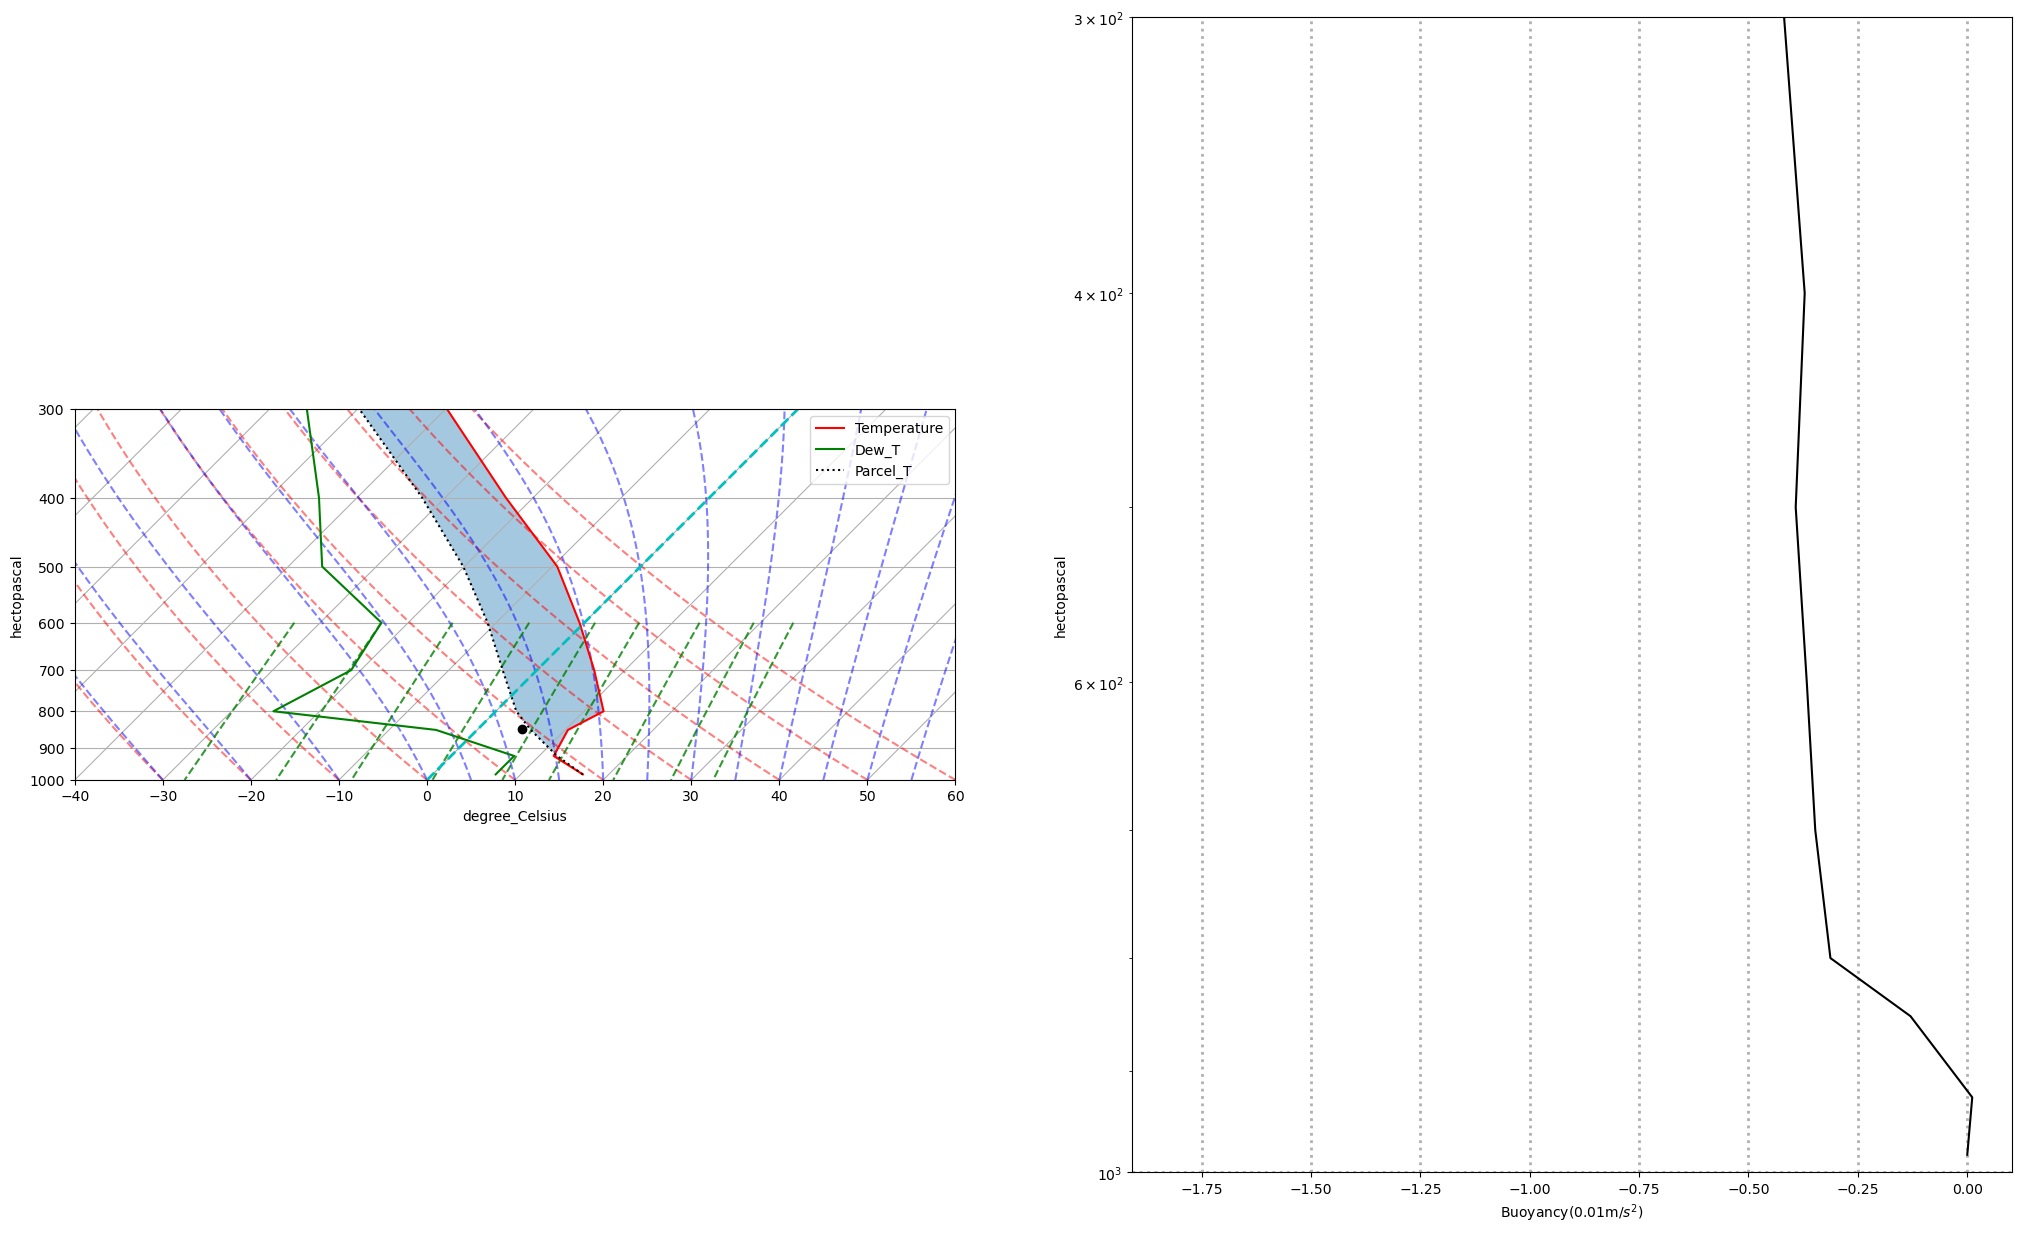

-3037.97587937459


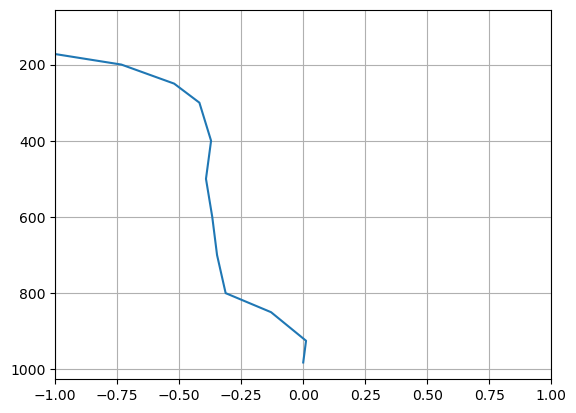

In [123]:
### we can use the same mixed parcel for both 

p_hpa = p_new_col * units.hPa

z_m = z_new_col * units.meter

t_degC = (t_new_col - 273.15) * units.degC

q_gkg = q_new_col * units('g/kg')

dewpt_degC = dewpoint_from_specific_humidity(p_hpa, q_gkg)

mp_pres, mp_temp, mp_dewpt = mixed_parcel(p_hpa, t_degC, dewpt_degC, depth=100*units.hPa, height=z_m)

mp_q = specific_humidity_from_dewpoint(mp_pres, mp_dewpt) * 1000

mp_temp = mp_temp.to("kelvin") # convert back to kelvin

## ammending t, q and p such that the bottom level now equals the mixed parcel values 

# updating temperature

t_mix = t_new_col.copy()

t_mix[0] = mp_temp.magnitude

# updating specific humidity 

q_mix = q_new_col.copy()

q_mix[0] = mp_q.magnitude

# # updating dewpoint

dewpt_mix = dewpt_degC.magnitude

dewpt_mix[0] = mp_dewpt.magnitude

# z_prof0 = z_new_col - z_new_col[0]

# print(z_prof0)

# temperature = Kelvin, dewpoint = Celsius, pressure = hPa, alt = meters

b = cal_buoyancy(t_profile = t_mix, h_profile = dewpt_mix, p_profile = p_new_col, alt_profile = z_new_col, 
                        entrain_opt = 2, td_r_q=1)

# keep only levels from surface up to 300 hPa (i.e., p >= 300)

mask = (p_new_col >= 300)

bp_300 = b.bp[mask]

z_300  = z_new_col[mask]

b_int_300 = np.trapz(bp_300, z_300)

print(b_int_300)

plt.plot(b.bp, p_new_col)

plt.xlim(-1, 1)

plt.grid()

plt.gca().invert_yaxis()

plt.show()